## 03 작업사항
1. 전처리 결과 로드
2. invalid cycle 표시
    - capacity_ah == 0인 cycle 4개
    - discharge_duration_sec 결측 4개
3. flag 표시
4. SoH 기준 capacity 계산
5. SoH 계산
6. EOL 기준 설정
7. RUL 계산

## 03 체크사항
1. battery_cycles.csv 또는 parquet을 정상 로드했는가?
2. row 수가 936개인가?
3. capacity_ah == 0인 row 4개가 invalid로 표시됐는가?
4. discharge_duration_sec 결측 row 4개가 invalid로 표시됐는가?
5. initial_capacity가 합리적인 값인가? 대략 1.13Ah 근처인가?
6. soh가 초기에는 1.0 근처인가?
7. soh가 시간이 지날수록 감소하는 경향인가?
8. SoH 80% 아래로 떨어지는 cycle이 있는가?
9. eol_cycle이 존재하면 rul이 정상 계산됐는가?
10. eol_cycle이 없으면 is_censored=True로 처리됐는가?
11. labeled CSV와 Parquet이 모두 저장됐는가?
12. CSV와 Parquet을 다시 읽었을 때 shape과 컬럼명이 같은가?

In [14]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
PROJECT_ROOT = Path("..").resolve()

CSV_INPUT_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "csv"
    / "battery_cycles.csv"
)

PARQUET_INPUT_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "paraquet"
    / "battery_cycles.parquet"
)

CSV_OUTPUT_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "csv"
    / "battery_cycles_labeled.csv"
)

PARQUET_OUTPUT_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "paraquet"
    / "battery_cycles_labeled.parquet"
)

EOL_THRESHOLD = 0.80
INITIAL_CAPACITY_WINDOW = 5

# 일시적인 SoH 급락을 EOL로 잘못 판단하지 않도록
# 5개 modeling cycle 연속 임계치 미만인 경우 EOL로 확정합니다.
EOL_CONFIRMATION_CYCLES = 5

In [ ]:
# 데이터로드 및 검증
if PARQUET_INPUT_PATH.exists():
    battery_cycles = pd.read_parquet(
        PARQUET_INPUT_PATH
    )
else:
    battery_cycles = pd.read_csv(
        CSV_INPUT_PATH
    )

required_cols = [
    "cell_id",
    "cycle",
    "capacity_ah",
    "cycle_type",
    "is_modeling_cycle",
]

missing_cols = [
    column
    for column in required_cols
    if column not in battery_cycles.columns
]

assert not missing_cols, (
    f"Missing columns: {missing_cols}"
)

battery_cycles = (
    battery_cycles
    .sort_values("cycle")
    .reset_index(drop=True)
)

print("input shape:", battery_cycles.shape)
print(
    battery_cycles["cycle_type"]
    .value_counts()
)

input shape: (886, 30)
cycle_type
standard_full_cycle    868
nonstandard_cycle       14
invalid                  4
Name: count, dtype: int64


In [ ]:
# Modeling Cycle 확인
modeling_mask = (
    battery_cycles["is_modeling_cycle"]
    .fillna(False)
    .astype(bool)
)

excluded_mask = ~modeling_mask

assert len(battery_cycles) == 886
assert modeling_mask.sum() == 868
assert excluded_mask.sum() == 18

assert (
    battery_cycles.loc[
        modeling_mask,
        "cycle_type",
    ]
    == "standard_full_cycle"
).all()

modeling_cycles = battery_cycles.loc[
    modeling_mask
].copy()

excluded_cycles = battery_cycles.loc[
    excluded_mask
].copy()

print("modeling cycles:", len(modeling_cycles))
print("excluded cycles:", len(excluded_cycles))

display(
    excluded_cycles[
        [
            "cycle",
            "source_file",
            "local_cycle",
            "capacity_ah",
            "cycle_type",
        ]
    ]
)

modeling cycles: 868
excluded cycles: 18


,cycle,source_file,local_cycle,capacity_ah,cycle_type
97,98,CS2_35_9_7_10.xlsx,45,0.000000,invalid
104,105,CS2_35_9_8_10.xlsx,7,0.916755,nonstandard_cycle
364,365,CS2_35_11_01_10.xlsx,10,0.922473,nonstandard_cycle
473,474,CS2_35_11_24_10.xlsx,9,0.000000,invalid
603,604,CS2_35_12_20_10.xlsx,30,0.737632,nonstandard_cycle
648,649,CS2_35_12_23_10.xlsx,25,0.000000,invalid
657,658,CS2_35_1_10_11.xlsx,9,0.671273,nonstandard_cycle
701,702,CS2_35_1_18_11.xlsx,3,0.639121,nonstandard_cycle
707,708,CS2_35_1_18_11.xlsx,9,0.621806,nonstandard_cycle
715,716,CS2_35_1_18_11.xlsx,17,0.596468,nonstandard_cycle


In [5]:
# Initial Capacity , SoH 계산
initial_capacity = float(
    modeling_cycles["capacity_ah"]
    .head(INITIAL_CAPACITY_WINDOW)
    .mean()
)

assert initial_capacity > 0

battery_cycles["initial_capacity"] = (
    initial_capacity
)

# 제외 cycle에는 공식 SoH 라벨을 생성하지 않습니다.
battery_cycles["soh"] = np.nan

battery_cycles.loc[
    modeling_mask,
    "soh",
] = (
    battery_cycles.loc[
        modeling_mask,
        "capacity_ah",
    ]
    / initial_capacity
)

battery_cycles["eol_threshold"] = (
    EOL_THRESHOLD
)

battery_cycles[
    "eol_confirmation_cycles"
] = EOL_CONFIRMATION_CYCLES

print("initial capacity:", initial_capacity)

display(
    battery_cycles.loc[
        modeling_mask,
        [
            "cycle",
            "capacity_ah",
            "initial_capacity",
            "soh",
        ],
    ].head(10)
)

initial capacity: 1.1364220858837624


,cycle,capacity_ah,initial_capacity,soh
0,1,1.138460,1.136422,1.001793
1,2,1.137728,1.136422,1.001149
2,3,1.137481,1.136422,1.000932
3,4,1.137092,1.136422,1.000590
4,5,1.131349,1.136422,0.995536
5,6,1.129366,1.136422,0.993791
6,7,1.123221,1.136422,0.988384
7,8,1.111035,1.136422,0.977661
8,9,1.106058,1.136422,0.973281
9,10,1.102627,1.136422,0.970262


In [6]:
# 지속 EOL Cycle 탐지
modeling_soh = (
    battery_cycles.loc[
        modeling_mask,
        ["cycle", "soh"],
    ]
    .reset_index(drop=True)
)

modeling_soh["below_eol_threshold"] = (
    modeling_soh["soh"]
    < EOL_THRESHOLD
)

# 단순 최초 임계치 미만 cycle을 확인합니다.
first_below_candidates = modeling_soh[
    modeling_soh["below_eol_threshold"]
]

if first_below_candidates.empty:
    first_below_cycle = pd.NA
else:
    first_below_cycle = int(
        first_below_candidates[
            "cycle"
        ].iloc[0]
    )

# 5개 modeling cycle 연속 임계치 미만인지 확인합니다.
sustained_eol = (
    modeling_soh[
        "below_eol_threshold"
    ]
    .rolling(
        window=EOL_CONFIRMATION_CYCLES,
        min_periods=EOL_CONFIRMATION_CYCLES,
    )
    .sum()
    .eq(EOL_CONFIRMATION_CYCLES)
)

if sustained_eol.any():
    confirmation_end_position = int(
        np.flatnonzero(
            sustained_eol.to_numpy()
        )[0]
    )

    eol_start_position = (
        confirmation_end_position
        - EOL_CONFIRMATION_CYCLES
        + 1
    )

    eol_cycle = int(
        modeling_soh.iloc[
            eol_start_position
        ]["cycle"]
    )

    is_censored = False
else:
    eol_cycle = pd.NA
    is_censored = True

print("first below 80%:", first_below_cycle)
print("sustained EOL cycle:", eol_cycle)
print("is censored:", is_censored)

first below 80%: 127
sustained EOL cycle: 546
is censored: False


In [8]:
# EOL , RUL 컬럼 생성
if is_censored:
    battery_cycles["eol_cycle"] = pd.Series(
        pd.NA,
        index=battery_cycles.index,
        dtype="Int64",
    )
else:
    battery_cycles["eol_cycle"] = pd.Series(
        eol_cycle,
        index=battery_cycles.index,
        dtype="Int64",
    )

battery_cycles["is_censored"] = (
    bool(is_censored)
)

# 제외 cycle의 RUL은 결측으로 유지합니다.
rul = pd.Series(
    pd.NA,
    index=battery_cycles.index,
    dtype="Int64",
)

rul_clipped = pd.Series(
    pd.NA,
    index=battery_cycles.index,
    dtype="Int64",
)

if not is_censored:
    raw_rul = (
        eol_cycle
        - battery_cycles.loc[
            modeling_mask,
            "cycle",
        ].astype(int)
    )

    rul.loc[modeling_mask] = raw_rul

    rul_clipped.loc[modeling_mask] = (
        raw_rul.clip(lower=0)
    )

battery_cycles["rul"] = rul
battery_cycles["rul_clipped"] = (
    rul_clipped
)

display(
    battery_cycles[
        battery_cycles["cycle"].between(
            eol_cycle - 5,
            eol_cycle + 10,
        )
    ][
        [
            "cycle",
            "capacity_ah",
            "soh",
            "is_modeling_cycle",
            "eol_cycle",
            "rul",
            "rul_clipped",
        ]
    ]
)

,cycle,capacity_ah,soh,is_modeling_cycle,eol_cycle,rul,rul_clipped
540,541,0.911196,0.801811,True,546,5,5
541,542,0.911760,0.802308,True,546,4,4
542,543,0.918676,0.808393,True,546,3,3
543,544,0.919322,0.808961,True,546,2,2
544,545,0.915469,0.805572,True,546,1,1
545,546,0.908205,0.799180,True,546,0,0
546,547,0.905165,0.796504,True,546,-1,0
547,548,0.908010,0.799008,True,546,-2,0
548,549,0.904317,0.795758,True,546,-3,0
549,550,0.901716,0.793469,True,546,-4,0


In [9]:
assert np.isclose(
    initial_capacity,
    1.1364220858837624,
)

assert first_below_cycle == 127
assert eol_cycle == 546
assert not is_censored

# 제외 cycle에는 공식 라벨이 없어야 합니다.
assert battery_cycles.loc[
    excluded_mask,
    "soh",
].isna().all()

assert battery_cycles.loc[
    excluded_mask,
    "rul",
].isna().all()

assert battery_cycles.loc[
    excluded_mask,
    "rul_clipped",
].isna().all()

# EOL cycle의 RUL은 0이어야 합니다.
eol_row = battery_cycles[
    battery_cycles["cycle"] == eol_cycle
].iloc[0]

assert eol_row["rul"] == 0
assert eol_row["rul_clipped"] == 0

# EOL 이후 clipped RUL은 음수가 없어야 합니다.
post_eol_modeling = (
    modeling_mask
    & (battery_cycles["cycle"] > eol_cycle)
)

assert (
    battery_cycles.loc[
        post_eol_modeling,
        "rul_clipped",
    ]
    == 0
).all()

assert (
    battery_cycles.loc[
        modeling_mask,
        "rul_clipped",
    ]
    >= 0
).all()

print("03 label validation passed.")

03 label validation passed.


In [10]:
label_summary = {
    "row_count": len(battery_cycles),
    "modeling_cycle_count": int(
        modeling_mask.sum()
    ),
    "excluded_cycle_count": int(
        excluded_mask.sum()
    ),
    "initial_capacity": initial_capacity,
    "soh_min": float(
        battery_cycles.loc[
            modeling_mask,
            "soh",
        ].min()
    ),
    "soh_max": float(
        battery_cycles.loc[
            modeling_mask,
            "soh",
        ].max()
    ),
    "eol_threshold": EOL_THRESHOLD,
    "eol_confirmation_cycles": (
        EOL_CONFIRMATION_CYCLES
    ),
    "first_below_cycle": first_below_cycle,
    "eol_cycle": eol_cycle,
    "is_censored": bool(is_censored),
}

label_summary

{'row_count': 886,
 'modeling_cycle_count': 868,
 'excluded_cycle_count': 18,
 'initial_capacity': 1.1364220858837624,
 'soh_min': 0.26719221094505163,
 'soh_max': 1.001793340193135,
 'eol_threshold': 0.8,
 'eol_confirmation_cycles': 5,
 'first_below_cycle': 127,
 'eol_cycle': 546,
 'is_censored': False}

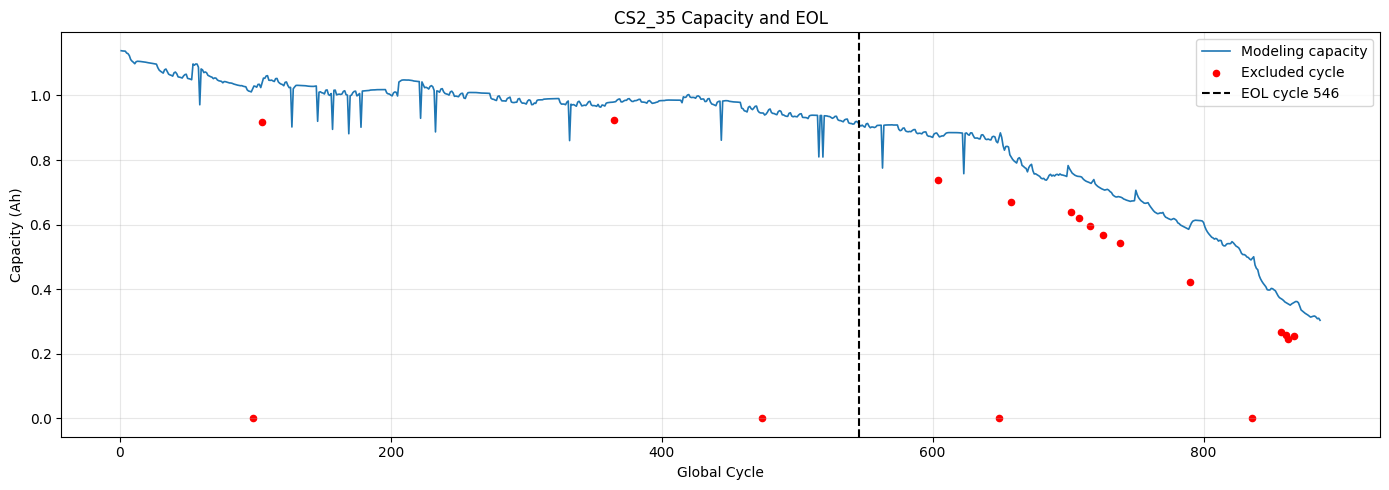

In [11]:
plt.figure(figsize=(14, 5))

plt.plot(
    battery_cycles.loc[
        modeling_mask,
        "cycle",
    ],
    battery_cycles.loc[
        modeling_mask,
        "capacity_ah",
    ],
    color="tab:blue",
    linewidth=1.2,
    label="Modeling capacity",
)

plt.scatter(
    battery_cycles.loc[
        excluded_mask,
        "cycle",
    ],
    battery_cycles.loc[
        excluded_mask,
        "capacity_ah",
    ],
    color="red",
    s=20,
    label="Excluded cycle",
)

plt.axvline(
    eol_cycle,
    color="black",
    linestyle="--",
    label=f"EOL cycle {eol_cycle}",
)

plt.title("CS2_35 Capacity and EOL")
plt.xlabel("Global Cycle")
plt.ylabel("Capacity (Ah)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

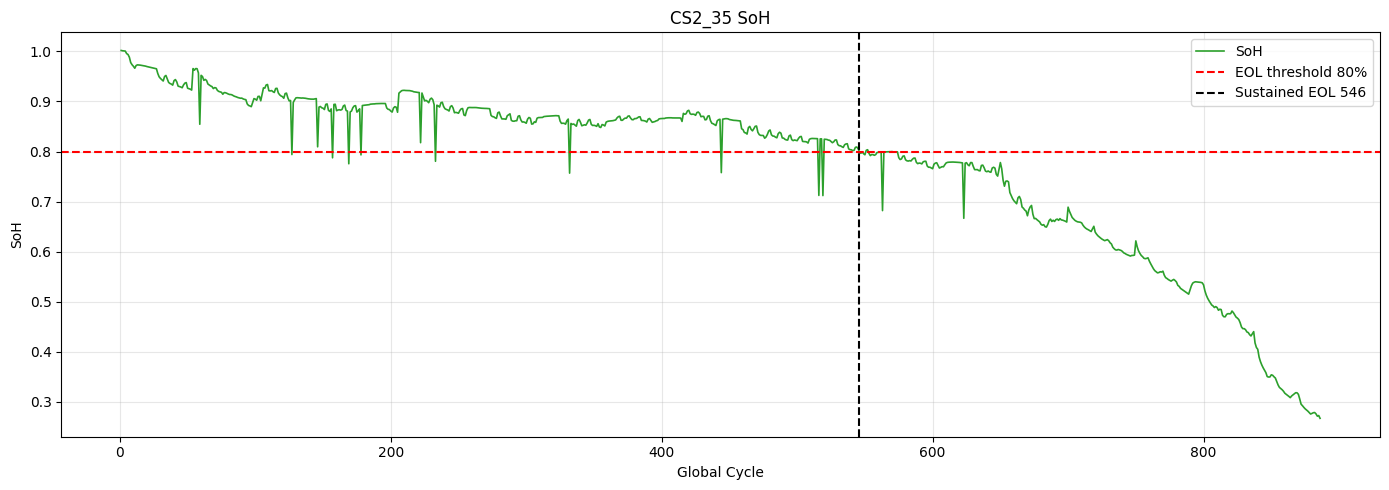

In [12]:
plt.figure(figsize=(14, 5))

plt.plot(
    battery_cycles.loc[
        modeling_mask,
        "cycle",
    ],
    battery_cycles.loc[
        modeling_mask,
        "soh",
    ],
    color="tab:green",
    linewidth=1.2,
    label="SoH",
)

plt.axhline(
    EOL_THRESHOLD,
    color="red",
    linestyle="--",
    label="EOL threshold 80%",
)

plt.axvline(
    eol_cycle,
    color="black",
    linestyle="--",
    label=f"Sustained EOL {eol_cycle}",
)

plt.title("CS2_35 SoH")
plt.xlabel("Global Cycle")
plt.ylabel("SoH")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
label_columns = [
    "initial_capacity",
    "soh",
    "eol_threshold",
    "eol_confirmation_cycles",
    "eol_cycle",
    "is_censored",
    "rul",
    "rul_clipped",
]

base_columns = [
    column
    for column in battery_cycles.columns
    if column not in label_columns
]

battery_cycles_labeled = battery_cycles[
    base_columns + label_columns
].copy()

assert battery_cycles_labeled.shape == (
    886,
    38,
)

CSV_OUTPUT_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

PARQUET_OUTPUT_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

battery_cycles_labeled.to_csv(
    CSV_OUTPUT_PATH,
    index=False,
)

battery_cycles_labeled.to_parquet(
    PARQUET_OUTPUT_PATH,
    index=False,
)

csv_check = pd.read_csv(
    CSV_OUTPUT_PATH
)

parquet_check = pd.read_parquet(
    PARQUET_OUTPUT_PATH
)

assert csv_check.shape == parquet_check.shape
assert list(csv_check.columns) == list(
    parquet_check.columns
)

assert np.allclose(
    csv_check["soh"],
    parquet_check["soh"],
    equal_nan=True,
)

print("CSV shape:", csv_check.shape)
print("Parquet shape:", parquet_check.shape)
print("03 outputs are consistent.")

CSV shape: (886, 38)
Parquet shape: (886, 38)
03 outputs are consistent.
